# Experiment D: Interpret Local PCA Axes Within Each Emotion

## Motivation

Previous analyses found that local PCA per emotion has a **participation ratio around 3–4**, meaning each named emotion has internal substructure. "Joy" is not a single direction — it contains multiple sub-axes.

The goal here is to **make these sub-axes interpretable** by finding the extreme examples on each PC and reading the associated texts. This is the foundation for turning local PCs into UI controls ("DJ knobs") in EmotionEngine that express subtle, unnamed feelings.

## Method

For each emotion $e$ at a primary layer (default: 13):

1. Load individual CAA vectors: $\delta[n,e] = h_{\text{emotion}}[n,e] - h_{\text{base}}[n]$ (pooled over intensities)
2. Optionally also run on residualized vectors $\delta^\text{resid}[n,e]$ (with common direction $g$ removed)
3. Fit local PCA within the emotion:
   $$X_e = \{\delta[n,e]\}_{n}, \quad \text{fit PCA with } K \text{ components}$$
4. For each PC $k$: find texts with the highest and lowest projection scores
5. Save a human-readable markdown report and a CSV/JSON with the examples
6. Generate an LLM interpretation prompt file

## What we're looking for

Examples of possible axes that might emerge (these are hypotheses, not assumptions):
- *calm joy* vs *excited joy*
- *private sadness* vs *social grief*
- *anger as irritation* vs *anger as moral outrage*
- *fear as uncertainty* vs *fear as immediate physical threat*
- *anticipation as hopeful planning* vs *anxious expectation*

The output should help decide whether local emotion PCs can serve as expressive "knobs" for subtle, unnamed affective states.

In [ ]:
from __future__ import annotations

import gc
import json
import textwrap
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.utils.extmath import randomized_svd

warnings.filterwarnings('ignore')

REPO_ROOT     = Path('../..').resolve()
ACT_DIR       = REPO_ROOT / 'activation' / 'emotion_rewrites'
EMO_NPY       = ACT_DIR / 'emotion_intensity_residual_stream.npy'
EMO_INFO      = ACT_DIR / 'emotion_intensity_residual_stream_info.json'
NEUTRAL_NPY   = ACT_DIR / 'neutral_paraphrase_residual_stream.npy'
NEUTRAL_INFO  = ACT_DIR / 'neutral_paraphrase_residual_stream_info.json'
CAA_PATH      = ACT_DIR / 'caa_emotion_directions.npz'
CAA_INFO      = ACT_DIR / 'caa_emotion_directions_info.json'
REWRITE_JSONL = REPO_ROOT / 'dataset' / 'emotion_rewrites' / 'emotion_rewrites.jsonl'

OUT_DIR       = REPO_ROOT / 'analysis' / 'caa' / 'local_pc_interpretation'
OUT_DIR.mkdir(parents=True, exist_ok=True)

PRIMARY_LAYER = 13
K_LOCAL       = 8      # local PCs to extract per emotion
N_EX          = 6      # extreme examples per pole per PC
MAX_SOURCES   = 3000   # source subsample; increase if RAM allows
SEED          = 42
RUN_RESIDUALIZED = True  # also run on g-residualized vectors

rng = np.random.default_rng(SEED)
sns.set_context('notebook')
sns.set_style('whitegrid')


In [ ]:
with open(EMO_INFO)     as f: EMO_META     = json.load(f)
with open(NEUTRAL_INFO) as f: NEUTRAL_META = json.load(f)
with open(CAA_INFO)     as f: CAA_META     = json.load(f)

# Validate source_id alignment
assert EMO_META['source_ids'] == NEUTRAL_META['source_ids'], (
    "source_ids mismatch between emotion and neutral-paraphrase info files. "
    "Re-extract activations with matching source_id order."
)

EMOTION_ORDER   = EMO_META['emotion_order']
INTENSITY_ORDER = EMO_META['intensity_order']
LAYER_INDICES   = EMO_META['layer_indices']
SOURCE_IDS      = EMO_META['source_ids']
SHAPE           = tuple(EMO_META['shape'])
DTYPE           = EMO_META.get('dtype', 'float32')
N, N_EMO, N_INT, N_LAY, D = SHAPE

LI_MAP  = {l: i for i, l in enumerate(LAYER_INDICES)}
EMO_POS = {e: i for i, e in enumerate(EMOTION_ORDER)}
INT_POS = {lvl: i for i, lvl in enumerate(INTENSITY_ORDER)}

ACT_EMO     = np.memmap(str(EMO_NPY),     dtype=DTYPE, mode='r', shape=SHAPE)
ACT_NEUTRAL = np.memmap(str(NEUTRAL_NPY), dtype='float32', mode='r', shape=tuple(NEUTRAL_META['shape']))

caa_data   = np.load(CAA_PATH)
CAA_POOLED = caa_data['caa_pooled']  # (8, 6, 4096)

# Source subsample (stable across runs)
if N > MAX_SOURCES:
    SRC_IDX = np.sort(rng.choice(N, size=MAX_SOURCES, replace=False))
else:
    SRC_IDX = np.arange(N)
N_SUB      = len(SRC_IDX)
SRC_ID_SUB = [SOURCE_IDS[i] for i in SRC_IDX]

print(f'Shape: {SHAPE}, dtype: {DTYPE}')
print(f'Using {N_SUB}/{N} sources. D={D}')
print(f'Emotions: {EMOTION_ORDER}')


Shape: (22782, 8, 3, 6, 4096), dtype: float32
Using 3000/22782 sources. D=4096
Emotions: ['joy', 'trust', 'fear', 'surprise', 'sadness', 'disgust', 'anger', 'anticipation']


In [3]:
# ── Build text registry: (source_id, emotion, intensity) → rewrite text ───────
# Also build base text registry: source_id → base_text
REGISTRY:      dict[tuple, str] = {}  # (sid, emo, lvl) → emotion rewrite
BASE_TEXT_REG: dict[str, str]   = {}  # sid → base text (same across intensity levels)

with open(REWRITE_JSONL) as f:
    for line in f:
        rec = json.loads(line)
        sid, lvl = rec['source_id'], rec['intensity_level']
        if sid not in BASE_TEXT_REG:
            BASE_TEXT_REG[sid] = rec.get('base_text', '')
        for emo in EMOTION_ORDER:
            text = rec.get(f'{emo}_rewrite', '')
            if text:
                REGISTRY[(sid, emo, lvl)] = text

print(f'Registry size: {len(REGISTRY)} (expected {N * N_EMO * N_INT})')
print(f'Base text registry size: {len(BASE_TEXT_REG)}')

Registry size: 546768 (expected 546768)
Base text registry size: 22782


In [ ]:

# -- Helpers ------------------------------------------------------------------

def unit(v: np.ndarray) -> np.ndarray:
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return v / (n + 1e-12)

def participation_ratio(s: np.ndarray) -> float:
    lam = s.astype(np.float64) ** 2
    return float(lam.sum() ** 2 / (lam ** 2).sum())

def load_delta_for_emotion(layer: int, emotion_idx: int) -> np.ndarray:
    """
    Memory-safe loader for one emotion at a time.

    Returns pooled per-source deltas with shape (N_SUB, D):
      delta[n] = mean_i(h_emotion[n, emotion_idx, i, layer] - h_neutral[n, layer])

    Loads one intensity slice at a time to avoid materialising the full
    (N_SUB, N_INT, D) block (~3× peak RAM of the per-intensity slice).
    """
    li = LI_MAP[layer]
    h_neutral = np.asarray(ACT_NEUTRAL[SRC_IDX, li, :], dtype=np.float32)  # (N_SUB, D)
    pooled    = np.zeros((len(SRC_IDX), D), dtype=np.float32)               # accumulator
    for i_int in range(N_INT):
        h_emo   = np.asarray(ACT_EMO[SRC_IDX, emotion_idx, i_int, li, :], dtype=np.float32)  # (N_SUB, D)
        pooled += h_emo - h_neutral
        del h_emo
    pooled /= N_INT
    del h_neutral
    gc.collect()
    return pooled

def compute_g(layer: int) -> np.ndarray:
    c = CAA_POOLED[:, LI_MAP[layer], :]  # (8, D)
    g_raw = c.mean(axis=0)
    return g_raw / (np.linalg.norm(g_raw) + 1e-12)

def residualize(X: np.ndarray, g: np.ndarray) -> np.ndarray:
    proj = (X @ g)[..., None]
    return X - proj * g

def truncate(text: str, max_chars: int = 120) -> str:
    return textwrap.shorten(text, width=max_chars, placeholder=' ...')

EMO_COLORS = {
    'joy': '#FFD700', 'trust': '#3cb44b', 'fear': '#008080',
    'surprise': '#4363d8', 'sadness': '#1e90ff', 'disgust': '#800080',
    'anger': '#e6194b', 'anticipation': '#f58231',
}

print('Helpers defined (streaming loader enabled).')


Helpers defined (streaming loader enabled).


## 1. Load per-source deltas and fit local PCA per emotion

For each emotion $e$, we extract the matrix $X_e = \{\delta[n,e]\}_{n=1}^{N}$ and fit PCA to find the internal structure.

We run this twice:
1. On the original deltas
2. On the residualized deltas (with common direction $g$ removed)

In [5]:
print(f'Preparing local PCA inputs at layer {PRIMARY_LAYER} (streaming, per emotion)...')
g = compute_g(PRIMARY_LAYER)  # (D,)

if RUN_RESIDUALIZED:
    print('Residualized run enabled: each emotion block will be g-residualized on the fly.')
else:
    print('Residualized run disabled: fitting only on original deltas.')

print(f'Number of sources used: {N_SUB}')
print(f'Embedding dimension D: {D}')
print(f'Fitting local PCA ({K_LOCAL} components) per emotion...')

Preparing local PCA inputs at layer 13 (streaming, per emotion)...
Residualized run enabled: each emotion block will be g-residualized on the fly.
Number of sources used: 3000
Embedding dimension D: 4096
Fitting local PCA (8 components) per emotion...


In [6]:

def fit_local_pca_streaming(
    layer: int,
    label: str,
    residualize_with_g: np.ndarray | None = None,
) -> dict:
    """
    Stream per-emotion loading to avoid large (N_SUB, N_EMO, N_INT, D) materialization.
    Returns LOCAL dict: {emotion: {'PCs', 'evr', 'pr', 'proj', 'mu'}}
    """
    LOCAL = {}
    for e_idx, emo in enumerate(EMOTION_ORDER):
        X_e = load_delta_for_emotion(layer, e_idx)  # (N_SUB, D)

        if residualize_with_g is not None:
            X_e = residualize(X_e, residualize_with_g).astype(np.float32, copy=False)

        mu  = X_e.mean(axis=0)
        Xc  = (X_e - mu).astype(np.float32, copy=False)
        del X_e   # free before SVD — cuts peak from 2× to 1× data size
        gc.collect()

        _, S_loc, Vt_loc = randomized_svd(
            Xc, n_components=K_LOCAL, random_state=SEED, n_iter=3
        )
        PCs_loc = Vt_loc.astype(np.float32)           # (K_LOCAL, D)
        proj = (Xc @ PCs_loc.T).astype(np.float32)    # (N_SUB, K_LOCAL)

        tv = float(np.einsum('ij,ij->', Xc.astype(np.float64), Xc.astype(np.float64)))
        evr = (S_loc ** 2) / (tv + 1e-12)
        pr = participation_ratio(S_loc)

        LOCAL[emo] = {
            'PCs': PCs_loc,
            'S': S_loc,
            'evr': evr,
            'proj': proj,
            'pr': pr,
            'mu': mu,
        }
        print(f'  [{label}] {emo:12s} PR={pr:.2f} EVR1={float(evr[0]):.3f}')

        del Xc, S_loc, Vt_loc
        gc.collect()

    return LOCAL

LOCAL_ORIG = fit_local_pca_streaming(
    PRIMARY_LAYER,
    label='original',
    residualize_with_g=None,
)
gc.collect()  # flush lingering buffers before second fit

if RUN_RESIDUALIZED:
    LOCAL_RESID = fit_local_pca_streaming(
        PRIMARY_LAYER,
        label='residualized',
        residualize_with_g=g,
    )

print('Local PCA fitted with streaming memory-safe pipeline.')


  [original] joy          PR=4.65 EVR1=0.152
  [original] trust        PR=5.00 EVR1=0.139
  [original] fear         PR=5.20 EVR1=0.131
  [original] surprise     PR=4.79 EVR1=0.153
  [original] sadness      PR=5.04 EVR1=0.139
  [original] disgust      PR=5.13 EVR1=0.134
  [original] anger        PR=5.09 EVR1=0.137
  [original] anticipation PR=4.97 EVR1=0.139
  [residualized] joy          PR=4.80 EVR1=0.144
  [residualized] trust        PR=5.17 EVR1=0.131
  [residualized] fear         PR=5.35 EVR1=0.125
  [residualized] surprise     PR=4.98 EVR1=0.145
  [residualized] sadness      PR=5.20 EVR1=0.132
  [residualized] disgust      PR=5.28 EVR1=0.126
  [residualized] anger        PR=5.27 EVR1=0.129
  [residualized] anticipation PR=5.13 EVR1=0.132
Local PCA fitted with streaming memory-safe pipeline.


In [7]:
# Summary table: PR and EVR per emotion
rows_evr = []
for suffix, LOCAL in [('orig', LOCAL_ORIG)] + ([('resid', LOCAL_RESID)] if RUN_RESIDUALIZED else []):
    for emo in EMOTION_ORDER:
        lp = LOCAL[emo]
        row = {'condition': suffix, 'emotion': emo, 'PR': round(lp['pr'], 2)}
        for k in range(K_LOCAL):
            row[f'EVR_PC{k+1}'] = round(float(lp['evr'][k]), 4)
        rows_evr.append(row)

df_evr = pd.DataFrame(rows_evr)
df_evr.to_csv(OUT_DIR / 'local_pca_evr.csv', index=False)
display(df_evr.set_index(['condition', 'emotion'])[['PR', 'EVR_PC1', 'EVR_PC2', 'EVR_PC3']].round(3))

PR  EVR_PC1  EVR_PC2  EVR_PC3
condition emotion                                      
orig      joy           4.65    0.152    0.082    0.050
          trust         5.00    0.138    0.065    0.048
          fear          5.20    0.131    0.070    0.049
          surprise      4.79    0.153    0.060    0.047
          sadness       5.04    0.139    0.076    0.054
          disgust       5.13    0.134    0.081    0.053
          anger         5.09    0.137    0.073    0.053
          anticipation  4.97    0.139    0.066    0.046
resid     joy           4.80    0.144    0.082    0.050
          trust         5.17    0.132    0.066    0.048
          fear          5.35    0.125    0.071    0.049
          surprise      4.98    0.145    0.060    0.048
          sadness       5.20    0.132    0.077    0.054
          disgust       5.28    0.126    0.082    0.052
          anger         5.27    0.129    0.074    0.053
          anticipation  5.13    0.132    0.067    0.045

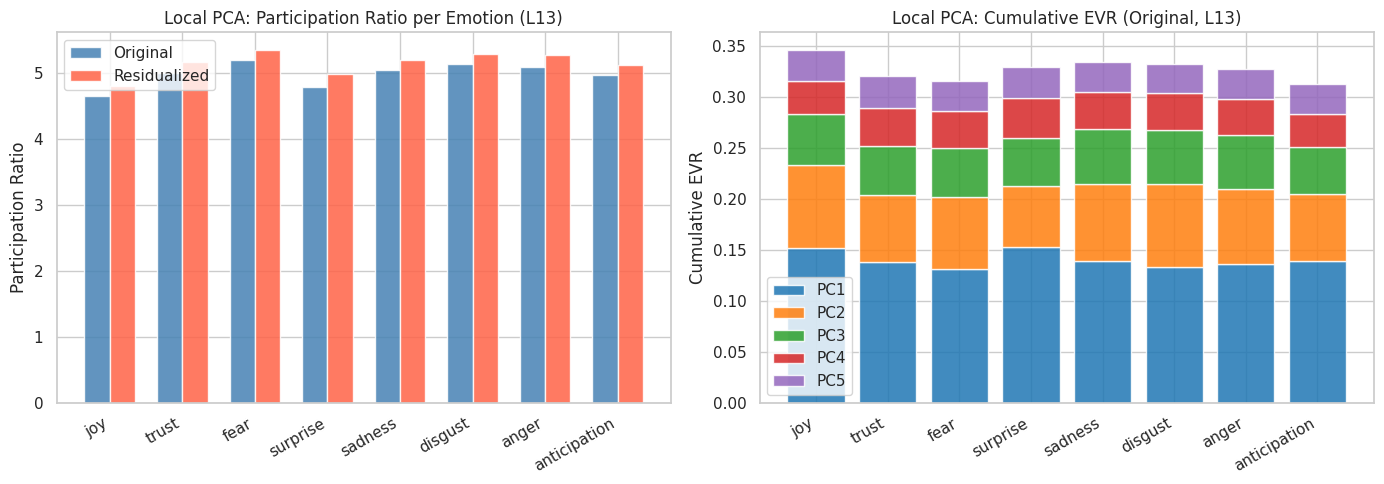

In [8]:
# Participation ratio comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(N_EMO)
w = 0.35
pr_orig  = [LOCAL_ORIG[emo]['pr']  for emo in EMOTION_ORDER]

axes[0].bar(x - (w/2 if RUN_RESIDUALIZED else 0), pr_orig, w, label='Original',
            color='steelblue', alpha=0.85)
if RUN_RESIDUALIZED:
    pr_resid = [LOCAL_RESID[emo]['pr'] for emo in EMOTION_ORDER]
    axes[0].bar(x + w/2, pr_resid, w, label='Residualized', color='tomato', alpha=0.85)

axes[0].set_xticks(x)
axes[0].set_xticklabels(EMOTION_ORDER, rotation=30, ha='right')
axes[0].set_ylabel('Participation Ratio')
axes[0].set_title(f'Local PCA: Participation Ratio per Emotion (L{PRIMARY_LAYER})')
axes[0].legend()

# EVR stacked bar for original
colors_pc = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
bottoms   = np.zeros(N_EMO)
for k in range(min(K_LOCAL, 5)):
    evr_k = [LOCAL_ORIG[emo]['evr'][k] for emo in EMOTION_ORDER]
    axes[1].bar(x, evr_k, bottom=bottoms, color=colors_pc[k], alpha=0.85, label=f'PC{k+1}')
    bottoms += np.array(evr_k)

axes[1].set_xticks(x)
axes[1].set_xticklabels(EMOTION_ORDER, rotation=30, ha='right')
axes[1].set_ylabel('Cumulative EVR')
axes[1].set_title(f'Local PCA: Cumulative EVR (Original, L{PRIMARY_LAYER})')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / f'local_pca_summary_L{PRIMARY_LAYER}.png', bbox_inches='tight')
plt.show()

## 2. Extreme examples per PC

For each emotion and each PC, we retrieve the source texts with the highest and lowest PC scores. These are the texts that most strongly push along each axis in either direction.

The pattern of these texts tells us what semantic or emotional dimension the PC captures.

In [9]:
def collect_extremes(
    LOCAL: dict,
    src_id_sub: list[str],
    n_ex: int = N_EX,
    condition: str = 'original',
    primary_pcs: int = 4,  # only collect for top PCs to limit output size
) -> list[dict]:
    """
    For each emotion and each PC, find the n_ex top positive and n_ex top negative
    examples. Return a list of dicts with full text information.
    """
    records = []
    for emo in EMOTION_ORDER:
        lp    = LOCAL[emo]
        proj  = lp['proj']  # (N_SUB, K_LOCAL)
        for k in range(min(primary_pcs, K_LOCAL)):
            scores  = proj[:, k]
            top_pos = np.argsort(scores)[-n_ex:][::-1]
            top_neg = np.argsort(scores)[:n_ex]
            for pole, indices in [('+', top_pos), ('-', top_neg)]:
                for rank, src_local_idx in enumerate(indices):
                    sid      = src_id_sub[src_local_idx]
                    # Use medium intensity for display (most representative)
                    lvl      = 'medium'
                    emo_text = REGISTRY.get((sid, emo, lvl), '')
                    if not emo_text:
                        # Try high then low
                        emo_text = REGISTRY.get((sid, emo, 'high'),
                                   REGISTRY.get((sid, emo, 'low'), '[missing]'))
                    base_text = BASE_TEXT_REG.get(sid, '[missing]')
                    records.append({
                        'condition':     condition,
                        'emotion':       emo,
                        'pc':            k + 1,
                        'pole':          pole,
                        'rank':          rank + 1,
                        'pc_score':      float(scores[src_local_idx]),
                        'evr':           float(lp['evr'][k]),
                        'source_id':     sid,
                        'base_text':     base_text,
                        'emotion_rewrite': emo_text,
                    })
    return records

extremes_orig = collect_extremes(LOCAL_ORIG, SRC_ID_SUB, condition='original')
df_extremes = pd.DataFrame(extremes_orig)

if RUN_RESIDUALIZED:
    extremes_resid = collect_extremes(LOCAL_RESID, SRC_ID_SUB, condition='residualized')
    df_extremes = pd.concat([df_extremes, pd.DataFrame(extremes_resid)], ignore_index=True)

df_extremes.to_csv(OUT_DIR / 'local_pc_extreme_examples.csv', index=False)
df_extremes.to_json(OUT_DIR / 'local_pc_extreme_examples.json', orient='records', indent=2)
print(f'Saved {len(df_extremes)} extreme example records.')

Saved 768 extreme example records.


## 3. Human-readable markdown report

Save a markdown file showing all extreme examples organized by emotion and PC.

In [10]:
def write_markdown_report(
    LOCAL: dict,
    src_id_sub: list[str],
    out_path: Path,
    condition: str = 'original',
    n_ex: int = N_EX,
    primary_pcs: int = 4,
) -> None:
    lines = [
        f'# Local PC Axis Interpretation — {condition.capitalize()}',
        f'',
        f'Layer: {PRIMARY_LAYER}  |  Sources: {N_SUB}  |  PCs shown: {primary_pcs}  |  Examples per pole: {n_ex}',
        f'',
    ]
    for emo in EMOTION_ORDER:
        lp = LOCAL[emo]
        lines += [
            f'---',
            f'',
            f'## Emotion: {emo.upper()}',
            f'',
            f'Participation Ratio: **{lp["pr"]:.2f}**  '
            f'| EVR: {" | ".join(f"PC{k+1}={lp["evr"][k]:.3f}" for k in range(primary_pcs))}',
            f'',
        ]
        for k in range(min(primary_pcs, K_LOCAL)):
            scores = lp['proj'][:, k]
            evr_k  = lp['evr'][k]
            lines += [
                f'### PC{k+1}  (EVR = {evr_k:.4f})',
                f'',
            ]
            for pole_label, indices in [
                ('TOP POSITIVE (high PC score)', np.argsort(scores)[-n_ex:][::-1]),
                ('TOP NEGATIVE (low PC score)',  np.argsort(scores)[:n_ex]),
            ]:
                lines += [f'**{pole_label}**', f'']
                for rank, src_local_idx in enumerate(indices):
                    sid      = src_id_sub[src_local_idx]
                    emo_text = REGISTRY.get((sid, emo, 'medium'),
                               REGISTRY.get((sid, emo, 'high'),
                               REGISTRY.get((sid, emo, 'low'), '[missing]')))
                    base     = BASE_TEXT_REG.get(sid, '[missing]')
                    sc       = float(scores[src_local_idx])
                    lines += [
                        f'{rank+1}. **[score={sc:+.3f}]**',
                        f'   - *Base text*: {truncate(base, 160)}',
                        f'   - *{emo.capitalize()} rewrite*: {truncate(emo_text, 160)}',
                        f'',
                    ]
    out_path.write_text('\n'.join(lines), encoding='utf-8')
    print(f'Written: {out_path}')

write_markdown_report(
    LOCAL_ORIG, SRC_ID_SUB,
    OUT_DIR / f'local_pc_report_original_L{PRIMARY_LAYER}.md',
    condition='original',
)
if RUN_RESIDUALIZED:
    write_markdown_report(
        LOCAL_RESID, SRC_ID_SUB,
        OUT_DIR / f'local_pc_report_residualized_L{PRIMARY_LAYER}.md',
        condition='residualized',
    )

Written: /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/local_pc_interpretation/local_pc_report_original_L13.md
Written: /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/local_pc_interpretation/local_pc_report_residualized_L13.md


## 4. Visual inspection: 2D PC scatter per emotion

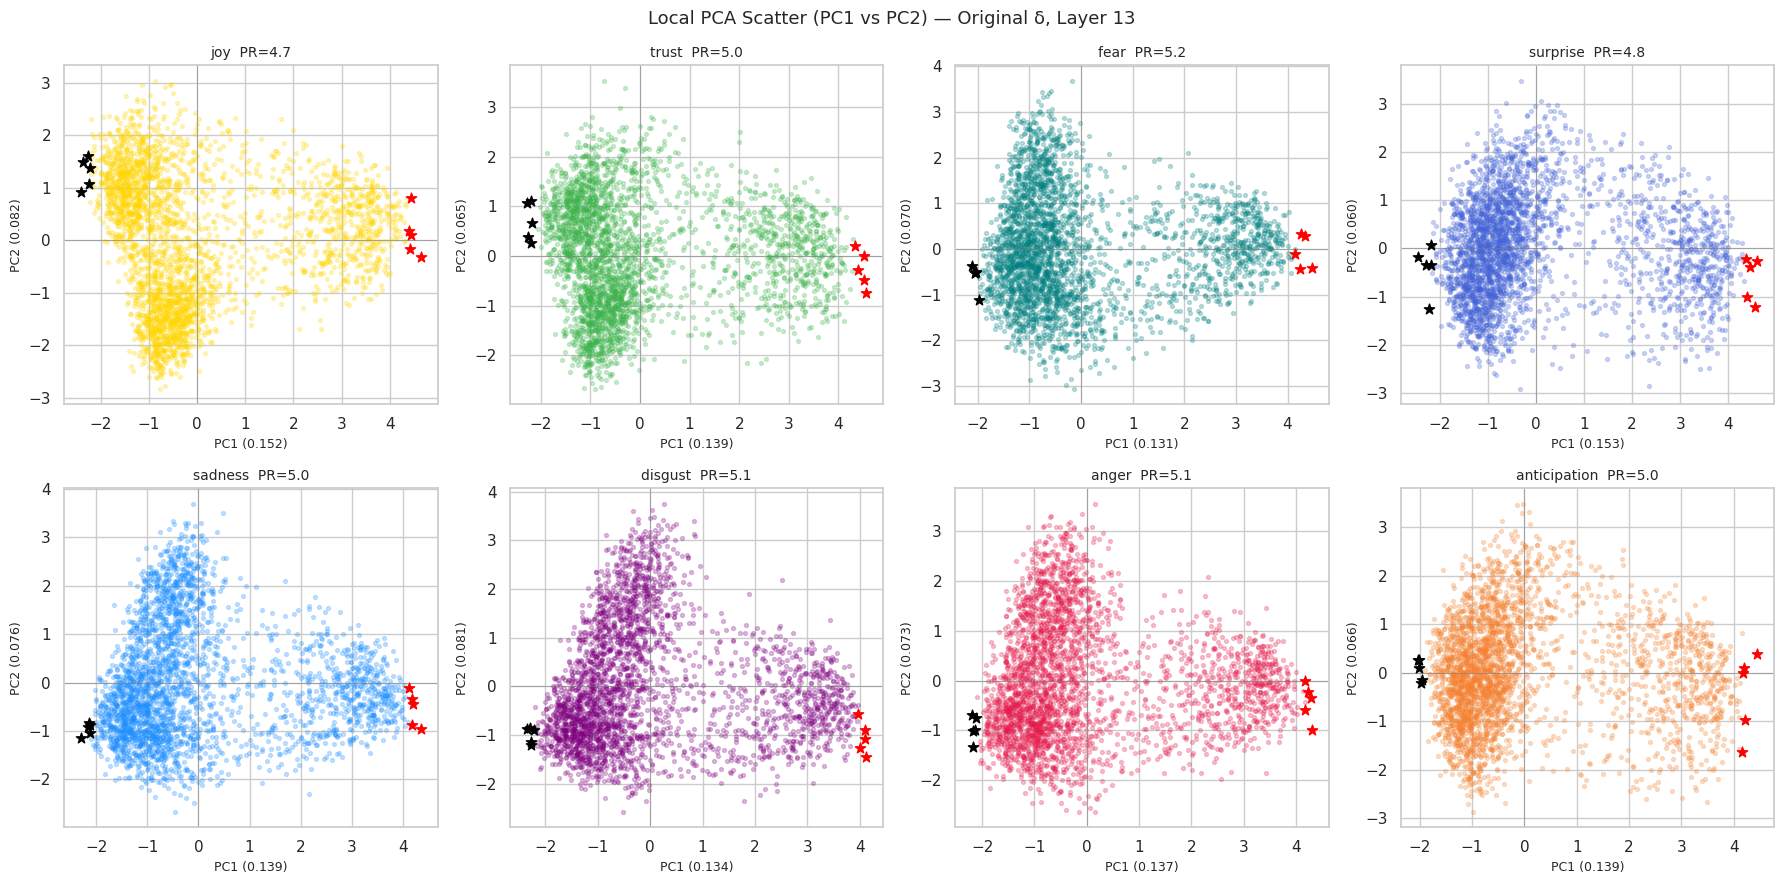

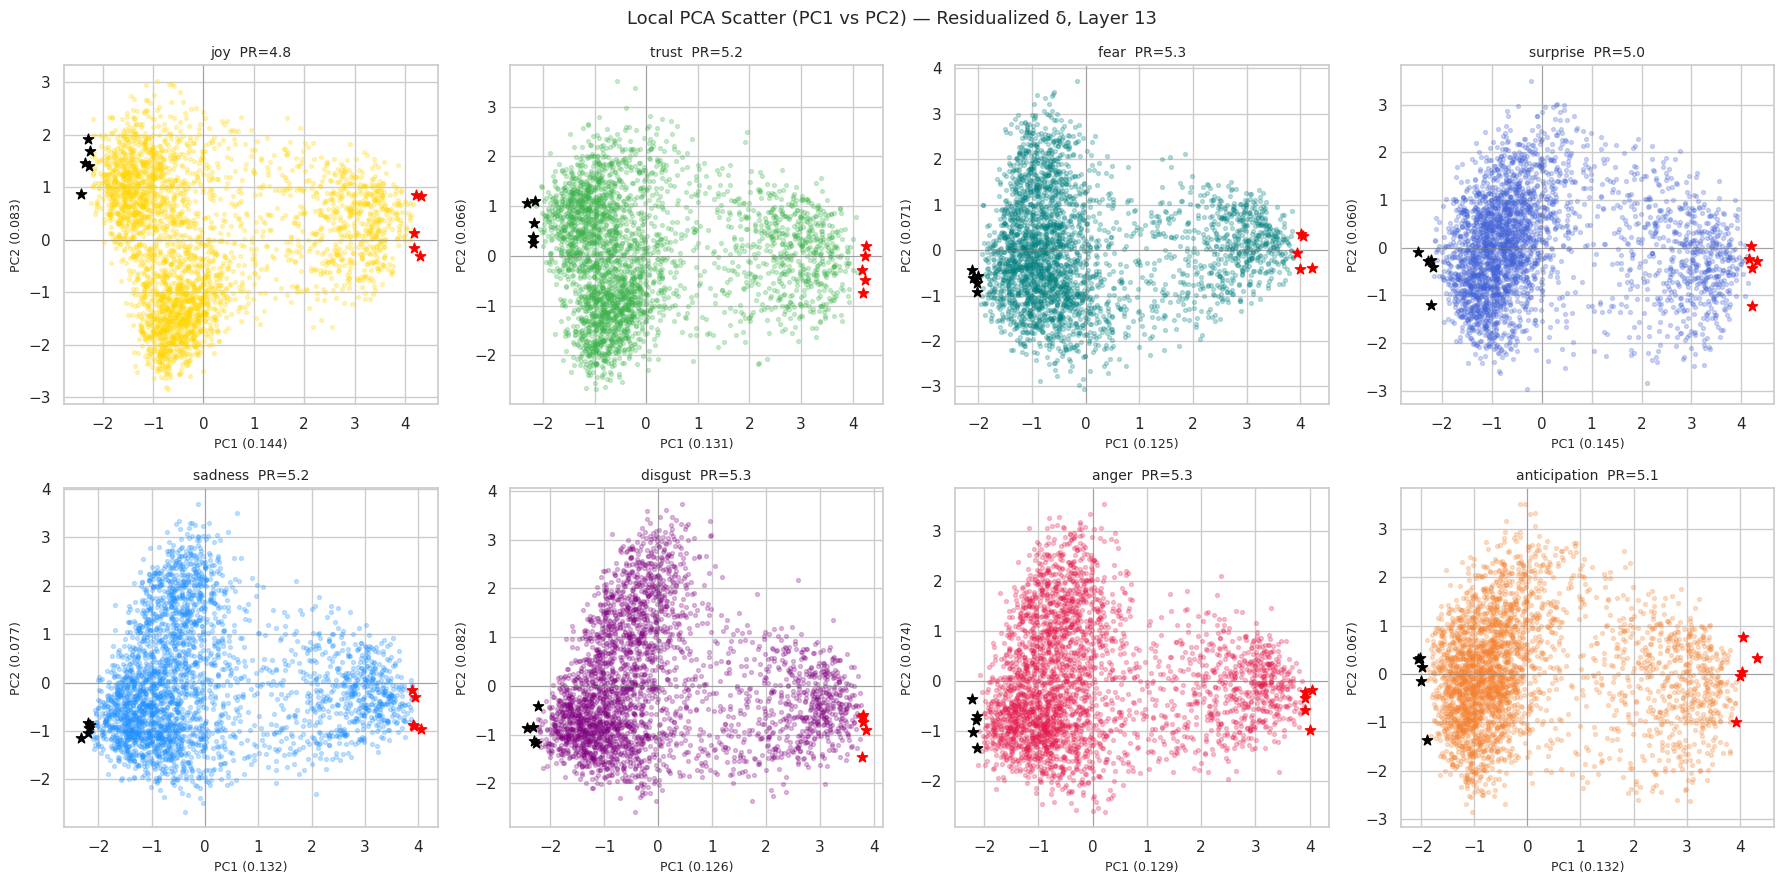

In [11]:
def plot_local_pca_scatter(LOCAL: dict, title_suffix: str, save_path: Path) -> None:
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    for ax, emo in zip(axes.flatten(), EMOTION_ORDER):
        lp   = LOCAL[emo]
        proj = lp['proj']  # (N_SUB, K_LOCAL)
        c    = EMO_COLORS.get(emo, 'gray')

        ax.scatter(proj[:, 0], proj[:, 1],
                   alpha=0.25, s=8, color=c)

        # Mark top/bottom extremes of PC1 as X
        n_mark = 5
        top = np.argsort(proj[:, 0])[-n_mark:]
        bot = np.argsort(proj[:, 0])[:n_mark]
        ax.scatter(proj[top, 0], proj[top, 1], s=60, color='red',   marker='*', zorder=3)
        ax.scatter(proj[bot, 0], proj[bot, 1], s=60, color='black', marker='*', zorder=3)

        ax.set_xlabel(f'PC1 ({lp["evr"][0]:.3f})', fontsize=9)
        ax.set_ylabel(f'PC2 ({lp["evr"][1]:.3f})', fontsize=9)
        ax.set_title(f'{emo}  PR={lp["pr"]:.1f}', fontsize=10)
        ax.axhline(0, color='gray', linewidth=0.4)
        ax.axvline(0, color='gray', linewidth=0.4)

    plt.suptitle(f'Local PCA Scatter (PC1 vs PC2) — {title_suffix}', fontsize=13)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

plot_local_pca_scatter(
    LOCAL_ORIG, f'Original δ, Layer {PRIMARY_LAYER}',
    OUT_DIR / f'local_pca_scatter_original_L{PRIMARY_LAYER}.png',
)
if RUN_RESIDUALIZED:
    plot_local_pca_scatter(
        LOCAL_RESID, f'Residualized δ, Layer {PRIMARY_LAYER}',
        OUT_DIR / f'local_pca_scatter_residualized_L{PRIMARY_LAYER}.png',
    )

## 5. LLM interpretation prompt file

Generate a structured prompt file that can be sent to an LLM to interpret each PC axis.

The LLM should read the positive and negative examples and infer what semantic or emotional axis the PC captures. This is the step that converts quantitative PCA results into named "DJ knobs" for EmotionEngine.

In [12]:
def write_llm_prompt(
    LOCAL: dict,
    src_id_sub: list[str],
    out_path: Path,
    condition: str = 'original',
    n_ex: int = 4,
    primary_pcs: int = 3,
) -> None:
    """Write a structured prompt file for LLM interpretation of local PCA axes."""
    system_prompt = """You are an expert in computational linguistics and affective science.
You are analyzing a language model's internal representation of emotions.

For each emotion and each principal component (PC) axis, you are given example texts
that score high (+) or low (-) on that axis. Your task is to:

1. Read the examples carefully.
2. Identify what emotional, semantic, or stylistic dimension the axis captures.
3. Give the axis a short name (e.g., "calm vs excited", "private vs social").
4. Explain in 2-3 sentences what makes high-scoring examples different from low-scoring ones.
5. Rate your confidence (1-5) that the axis is semantically interpretable.

Format your response as JSON:
{"emotion": ..., "pc": ..., "axis_name": ..., "description": ..., "confidence": ...}

Important notes:
- Do NOT assume the axis will match Plutchik wheel predictions.
- If examples seem random or uninterpretable, say so honestly.
- The axes may capture writing style, social context, arousal level, or any other dimension.
"""

    sections = []
    for emo in EMOTION_ORDER:
        lp = LOCAL[emo]
        for k in range(min(primary_pcs, K_LOCAL)):
            scores  = lp['proj'][:, k]
            top_pos = np.argsort(scores)[-n_ex:][::-1]
            top_neg = np.argsort(scores)[:n_ex]

            pos_texts = []
            for idx in top_pos:
                sid   = src_id_sub[idx]
                text  = REGISTRY.get((sid, emo, 'medium'),
                        REGISTRY.get((sid, emo, 'high'),
                        REGISTRY.get((sid, emo, 'low'), '[missing]')))
                base  = BASE_TEXT_REG.get(sid, '[missing]')
                pos_texts.append({'base': truncate(base, 200),
                                   'rewrite': truncate(text, 200),
                                   'score': round(float(scores[idx]), 3)})

            neg_texts = []
            for idx in top_neg:
                sid   = src_id_sub[idx]
                text  = REGISTRY.get((sid, emo, 'medium'),
                        REGISTRY.get((sid, emo, 'high'),
                        REGISTRY.get((sid, emo, 'low'), '[missing]')))
                base  = BASE_TEXT_REG.get(sid, '[missing]')
                neg_texts.append({'base': truncate(base, 200),
                                   'rewrite': truncate(text, 200),
                                   'score': round(float(scores[idx]), 3)})

            sections.append({
                'emotion':    emo,
                'pc':         k + 1,
                'evr':        round(float(lp['evr'][k]), 4),
                'pr':         round(lp['pr'], 2),
                'condition':  condition,
                'high_examples': pos_texts,
                'low_examples':  neg_texts,
            })

    payload = {
        'system_prompt': system_prompt,
        'layer':         PRIMARY_LAYER,
        'condition':     condition,
        'n_sources':     N_SUB,
        'axes':          sections,
    }

    out_path.write_text(json.dumps(payload, indent=2, ensure_ascii=False), encoding='utf-8')
    print(f'Written LLM prompt: {out_path}  ({len(sections)} axes)')

write_llm_prompt(
    LOCAL_ORIG, SRC_ID_SUB,
    OUT_DIR / f'llm_interpretation_prompt_original_L{PRIMARY_LAYER}.json',
    condition='original',
)
if RUN_RESIDUALIZED:
    write_llm_prompt(
        LOCAL_RESID, SRC_ID_SUB,
        OUT_DIR / f'llm_interpretation_prompt_residualized_L{PRIMARY_LAYER}.json',
        condition='residualized',
    )

Written LLM prompt: /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/local_pc_interpretation/llm_interpretation_prompt_original_L13.json  (24 axes)
Written LLM prompt: /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/local_pc_interpretation/llm_interpretation_prompt_residualized_L13.json  (24 axes)


## 6. Alignment: do local PCs align with the common direction $g$?

If local PC1 of each emotion is highly aligned with the common emotionalization direction $g$, that means the within-emotion structure is mainly intensity/style rather than emotion-specific substructure.

After residualization, local PC1 should be orthogonal to $g$ by construction.

In [13]:
rows_align = []
for cond, LOCAL in [('original', LOCAL_ORIG)] + ([('residualized', LOCAL_RESID)] if RUN_RESIDUALIZED else []):
    for emo in EMOTION_ORDER:
        lp = LOCAL[emo]
        for k in range(K_LOCAL):
            pc = lp['PCs'][k]
            cos_g = abs(float(unit(pc[None, :])[0] @ g))
            rows_align.append({
                'condition': cond,
                'emotion':   emo,
                'pc':        k + 1,
                'evr':       float(lp['evr'][k]),
                'cos_with_g': cos_g,
            })

df_align = pd.DataFrame(rows_align)
df_align.to_csv(OUT_DIR / 'local_pc_g_alignment.csv', index=False)

# Show PC1 alignment for each emotion
pc1_orig  = df_align[(df_align.condition == 'original') & (df_align.pc == 1)]
print('PC1 |cos| with g (original):')
print(pc1_orig.set_index('emotion')[['evr', 'cos_with_g']].round(4).to_string())

PC1 |cos| with g (original):
                 evr  cos_with_g
emotion                         
joy           0.1516      0.2513
trust         0.1385      0.2528
fear          0.1312      0.2482
surprise      0.1528      0.2579
sadness       0.1390      0.2578
disgust       0.1336      0.2637
anger         0.1366      0.2674
anticipation  0.1389      0.2452


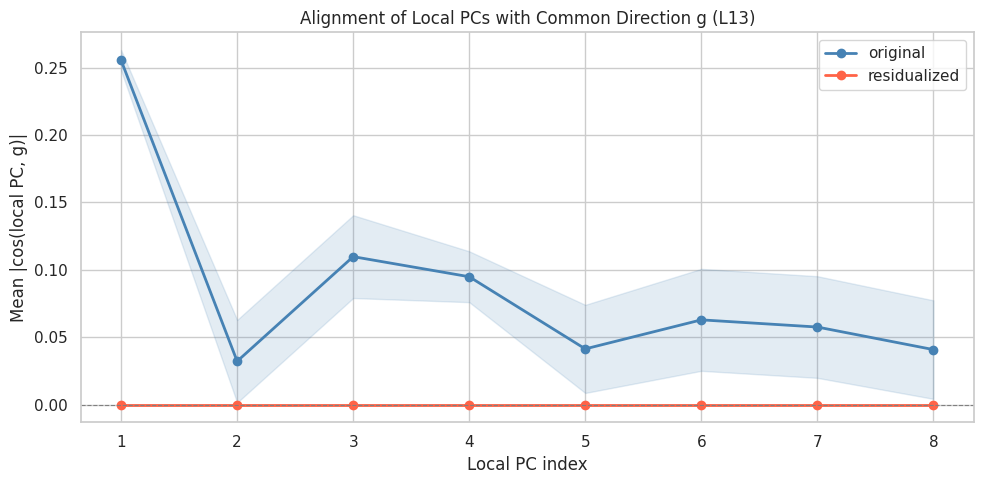

In [14]:
# Plot: |cos(local PC_k, g)| per PC index, per condition
fig, ax = plt.subplots(figsize=(10, 5))

for cond, color in [('original', 'steelblue'), ('residualized', 'tomato')]:
    if cond == 'residualized' and not RUN_RESIDUALIZED:
        continue
    sub = df_align[df_align.condition == cond]
    # Mean across emotions per PC index
    mean_cos = sub.groupby('pc')['cos_with_g'].mean()
    std_cos  = sub.groupby('pc')['cos_with_g'].std()
    ax.plot(mean_cos.index, mean_cos.values, marker='o', label=cond, color=color, linewidth=2)
    ax.fill_between(mean_cos.index,
                    mean_cos - std_cos, mean_cos + std_cos,
                    alpha=0.15, color=color)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Local PC index')
ax.set_ylabel('Mean |cos(local PC, g)|')
ax.set_title(f'Alignment of Local PCs with Common Direction g (L{PRIMARY_LAYER})')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / f'local_pc_g_alignment_L{PRIMARY_LAYER}.png', bbox_inches='tight')
plt.show()

### Using the LLM prompt

Send `llm_interpretation_prompt_residualized_L13.json` to an LLM API. The JSON contains:
- `system_prompt`: Instructions for the LLM
- `axes`: One entry per (emotion, PC), with 4 high-scoring and 4 low-scoring examples

The LLM returns axis names and descriptions. These then become candidate "DJ knob" labels for EmotionEngine.

### Interpretation guide

| Observation | Interpretation |
|---|---|
| PR > 2 for most emotions | Internal emotional substructure exists |
| Local PC1 highly aligned with $g$ (|cos| > 0.8) | PC1 mainly captures intensity/emotionalization, not subtle differences |
| Residualized PC1 NOT aligned with $g$ | Residualization is working correctly |
| Extreme examples show clear semantic contrasts | PCs are interpretable and potentially useful as knobs |
| Extreme examples appear random | PC captures noise or source-specific artifacts |

In [15]:
# Residualized local-PC interpretation worksheet from collected extremes
df_extremes_resid = pd.DataFrame(extremes_resid)

def join_examples(block: pd.DataFrame, text_col: str = 'emotion_rewrite', max_items: int = 4) -> str:
    block = block.sort_values('rank').head(max_items)
    return '\n'.join(
        f"- ({row['pc_score']:+.3f}) {truncate(row[text_col], 140)}"
        for _, row in block.iterrows()
    )

axis_rows = []
for (emotion, pc), grp in df_extremes_resid.groupby(['emotion', 'pc'], sort=True):
    pos = grp[grp['pole'] == '+'].copy()
    neg = grp[grp['pole'] == '-'].copy()

    axis_rows.append({
        'emotion': emotion,
        'pc': pc,
        'evr': float(grp['evr'].iloc[0]),
        'n_pos': len(pos),
        'n_neg': len(neg),
        'pos_score_mean': float(pos['pc_score'].mean()) if len(pos) else np.nan,
        'neg_score_mean': float(neg['pc_score'].mean()) if len(neg) else np.nan,
        'positive_examples': join_examples(pos),
        'negative_examples': join_examples(neg),
    })

axis_preview_df = pd.DataFrame(axis_rows).sort_values(['emotion', 'pc']).reset_index(drop=True)
axis_preview_df.to_csv(OUT_DIR / f'axis_preview_residualized_L{PRIMARY_LAYER}.csv', index=False)

display(axis_preview_df[['emotion', 'pc', 'evr', 'pos_score_mean', 'neg_score_mean']].round(3))

md_lines = [
    f'# Residualized Axis Preview — Layer {PRIMARY_LAYER}',
    '',
    'Use this as a compact worksheet before sending examples to an LLM.',
    '',
]
for _, row in axis_preview_df.iterrows():
    md_lines += [
        f"## {row['emotion'].upper()} — PC{int(row['pc'])} (EVR={row['evr']:.4f})",
        '',
        '**High-scoring examples**',
        row['positive_examples'],
        '',
        '**Low-scoring examples**',
        row['negative_examples'],
        '',
    ]

axis_preview_md = OUT_DIR / f'axis_preview_residualized_L{PRIMARY_LAYER}.md'
axis_preview_md.write_text('\n'.join(md_lines), encoding='utf-8')
print(f'Wrote: {axis_preview_md}')

,emotion,pc,evr,pos_score_mean,neg_score_mean
0,anger,1,0.129,3.949,-2.157
1,anger,2,0.074,3.301,-2.550
2,anger,3,0.053,2.938,-2.656
3,anger,4,0.035,2.432,-2.014
4,anticipation,1,0.132,4.052,-1.982
5,anticipation,2,0.067,3.306,-2.676
6,anticipation,3,0.045,2.601,-2.523
7,anticipation,4,0.033,2.158,-2.076
8,disgust,1,0.126,3.801,-2.296
9,disgust,2,0.082,3.551,-2.358


Wrote: /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/local_pc_interpretation/axis_preview_residualized_L13.md


## Summary

Outputs saved to `analysis/caa/local_pc_interpretation/`:

| File | Contents |
|---|---|
| `local_pca_evr.csv` | PR and EVR per emotion per condition |
| `local_pc_extreme_examples.csv` | Extreme texts for each PC, structured |
| `local_pc_extreme_examples.json` | Same, JSON format |
| `local_pc_report_original_L13.md` | Human-readable report (original) |
| `local_pc_report_residualized_L13.md` | Human-readable report (residualized) |
| `llm_interpretation_prompt_*.json` | Structured prompt for LLM axis interpretation |
| `llm_axis_interpretations_residualized_L13.json` | OpenAI-generated axis names and descriptions |
| `llm_axis_judgements_residualized_L13.json` | LLM-as-judge scoring and rationale per axis |
| `llm_axis_judgements_residualized_L13.csv` | Tabular judge results for downstream filtering |
| `local_pc_g_alignment.csv` | How much each PC aligns with $g$ |
| PNG plots | Scatter plots, EVR bars |

## 7. OpenAI API Interpretation and LLM-as-Judge

This section sends the residualized axis prompt JSON to the OpenAI API, stores one interpretation per axis, and then runs a second LLM judge pass to score whether each axis looks interpretable and useful as a candidate EmotionEngine control.

Required environment variables:
- `OPENAI_API_KEY`: your API key
- `OPENAI_MODEL`: optional, defaults to `gpt-4.1-mini`
- `OPENAI_JUDGE_MODEL`: optional, defaults to `OPENAI_MODEL`

Outputs written to `analysis/caa/local_pc_interpretation/`:
- `llm_axis_interpretations_residualized_L13.json`
- `llm_axis_judgements_residualized_L13.json`
- `llm_axis_judgements_residualized_L13.csv`

In [23]:
from openai import OpenAI
import os
import time

OPENAI_MODEL = os.environ.get('OPENAI_MODEL', 'gpt-5.4')
OPENAI_JUDGE_MODEL = os.environ.get('OPENAI_JUDGE_MODEL', OPENAI_MODEL)
REQUEST_DELAY_S = float(os.environ.get('OPENAI_REQUEST_DELAY_S', '0.2'))
DEFAULT_MAX_AXES = int(os.environ.get('OPENAI_MAX_AXES', '4'))

AXIS_PROMPT_PATH = OUT_DIR / f'llm_interpretation_prompt_residualized_L{PRIMARY_LAYER}.json'
INTERPRETATION_PATH = OUT_DIR / f'llm_axis_interpretations_residualized_L{PRIMARY_LAYER}.json'
JUDGE_PATH = OUT_DIR / f'llm_axis_judgements_residualized_L{PRIMARY_LAYER}.json'
JUDGE_CSV_PATH = OUT_DIR / f'llm_axis_judgements_residualized_L{PRIMARY_LAYER}.csv'

JUDGE_GUIDE = '''
Use this rubric when judging the proposed axis interpretation:
- PR > 2 suggests meaningful within-emotion substructure.
- High alignment with g in the original basis often means generic emotionalization rather than a subtle emotion-specific knob.
- Residualized axes should not mainly collapse back onto g.
- Clear semantic contrast across high vs low examples is evidence for interpretability.
- Random or heterogeneous examples suggest noise, artifacts, or dataset leakage.
'''

def require_openai_client() -> OpenAI:
    api_key = os.environ.get('OPENAI_API_KEY')
    if not api_key:
        raise RuntimeError('Set OPENAI_API_KEY in the environment before running the API call cells.')
    return OpenAI(api_key=api_key)

def response_to_text(response) -> str:
    text = getattr(response, 'output_text', None)
    if text:
        return text.strip()
    parts = []
    for item in getattr(response, 'output', []):
        for content in getattr(item, 'content', []):
            piece = getattr(content, 'text', None)
            if piece:
                parts.append(piece)
    return '\n'.join(parts).strip()

def parse_json_text(text: str) -> dict:
    text = text.strip()
    if text.startswith('```'):
        lines = text.splitlines()
        if len(lines) >= 3:
            text = '\n'.join(lines[1:-1]).strip()
    return json.loads(text)

def call_json_response(client: OpenAI, model: str, instructions: str, prompt: str) -> dict:
    response = client.responses.create(
        model=model,
        instructions=instructions,
        input=prompt,
    )
    raw = response_to_text(response)
    if not raw:
        raise ValueError('Model returned an empty response.')
    return parse_json_text(raw)

def format_examples(examples: list[dict]) -> str:
    return '\n'.join(
        f"- score={ex['score']:+.3f} | base={ex['base']} | rewrite={ex['rewrite']}"
        for ex in examples
    )

def residualized_alignment(emotion: str, pc: int) -> float:
    block = df_align[
        (df_align['condition'] == 'residualized')
        & (df_align['emotion'] == emotion)
        & (df_align['pc'] == pc)
    ]
    if block.empty:
        return float('nan')
    return float(block['cos_with_g'].iloc[0])

def axis_key(record: dict) -> str:
    return f"{record['emotion']}::PC{int(record['pc'])}"

def clean_text(value: object) -> str:
    return ' '.join(str(value).strip().split())

def normalize_interpretation_record(record: dict) -> dict:
    normalized = dict(record)
    normalized['emotion'] = clean_text(normalized['emotion']).lower()
    normalized['pc'] = int(normalized['pc'])
    normalized['axis_name'] = clean_text(normalized['axis_name'])
    normalized['description'] = clean_text(normalized['description'])
    normalized['contrast_summary'] = clean_text(normalized['contrast_summary'])
    normalized['confidence'] = int(normalized['confidence'])
    keep_as_knob = normalized.get('keep_as_knob', False)
    if isinstance(keep_as_knob, str):
        keep_as_knob = keep_as_knob.strip().lower() in {'true', 'yes', '1'}
    normalized['keep_as_knob'] = bool(keep_as_knob)
    return normalized

def normalize_judgement_record(record: dict) -> dict:
    normalized = dict(record)
    normalized['emotion'] = clean_text(normalized['emotion']).lower()
    normalized['pc'] = int(normalized['pc'])
    normalized['axis_name'] = clean_text(normalized['axis_name'])
    normalized['suggested_axis_name'] = clean_text(normalized['suggested_axis_name'])
    normalized['interpretability_score'] = int(normalized['interpretability_score'])
    normalized['knob_readiness_score'] = int(normalized['knob_readiness_score'])
    normalized['verdict'] = clean_text(normalized['verdict']).lower()
    normalized['rationale'] = clean_text(normalized['rationale'])
    concerns = normalized.get('concerns', [])
    if isinstance(concerns, str):
        concerns = [concerns] if concerns.strip() else []
    normalized['concerns'] = [clean_text(item) for item in concerns]
    return normalized

def load_saved_axes(path: Path) -> dict[str, dict]:
    if not path.exists():
        return {}
    payload = json.loads(path.read_text(encoding='utf-8'))
    return {axis_key(rec): rec for rec in payload.get('axes', [])}

def write_pipeline_outputs(
    interpretations: dict[str, dict],
    judgements: dict[str, dict],
) -> pd.DataFrame:
    normalized_interpretations = {
        key: normalize_interpretation_record(rec)
        for key, rec in interpretations.items()
    }
    normalized_judgements = {
        key: normalize_judgement_record(rec)
        for key, rec in judgements.items()
    }

    interpretation_payload = {
        'layer': PRIMARY_LAYER,
        'condition': 'residualized',
        'model': OPENAI_MODEL,
        'n_completed': len(normalized_interpretations),
        'axes': list(normalized_interpretations.values()),
    }
    judge_payload = {
        'layer': PRIMARY_LAYER,
        'condition': 'residualized',
        'judge_model': OPENAI_JUDGE_MODEL,
        'n_completed': len(normalized_judgements),
        'axes': list(normalized_judgements.values()),
    }

    INTERPRETATION_PATH.write_text(
        json.dumps(interpretation_payload, indent=2, ensure_ascii=False),
        encoding='utf-8',
    )
    JUDGE_PATH.write_text(
        json.dumps(judge_payload, indent=2, ensure_ascii=False),
        encoding='utf-8',
    )

    judge_df = pd.DataFrame(normalized_judgements.values())
    if not judge_df.empty:
        judge_df = judge_df.sort_values(['emotion', 'pc']).reset_index(drop=True)
        judge_df.to_csv(JUDGE_CSV_PATH, index=False)
    return judge_df

def interpret_axis(client: OpenAI, system_prompt: str, axis: dict) -> dict:
    prompt = f'''Interpret one residualized local PCA axis and return JSON only.
emotion: {axis['emotion']}
pc: {axis['pc']}
condition: {axis['condition']}
evr: {axis['evr']:.4f}
pr: {axis['pr']:.2f}

High-scoring examples:
{format_examples(axis['high_examples'])}

Low-scoring examples:
{format_examples(axis['low_examples'])}

Return exactly this JSON object shape:
{{
  "emotion": string,
  "pc": integer,
  "axis_name": string,
  "description": string,
  "confidence": integer,
  "contrast_summary": string,
  "keep_as_knob": boolean
}}
'''
    result = call_json_response(
        client,
        OPENAI_MODEL,
        system_prompt + '\nReturn valid JSON only. Do not wrap the JSON in markdown fences.',
        prompt,
    )
    result['model'] = OPENAI_MODEL
    result['condition'] = axis['condition']
    result['evr'] = float(axis['evr'])
    result['pr'] = float(axis['pr'])
    result['cos_with_g_residualized'] = residualized_alignment(axis['emotion'], int(axis['pc']))
    return normalize_interpretation_record(result)

def judge_axis(client: OpenAI, axis: dict, interpretation: dict) -> dict:
    prompt = f'''Judge whether this interpreted residualized PCA axis is a strong candidate EmotionEngine control.

{JUDGE_GUIDE}

Axis metadata:
emotion: {axis['emotion']}
pc: {axis['pc']}
evr: {axis['evr']:.4f}
pr: {axis['pr']:.2f}
residualized |cos(axis, g)|: {residualized_alignment(axis['emotion'], int(axis['pc'])):.4f}

Proposed interpretation:
axis_name: {interpretation['axis_name']}
description: {interpretation['description']}
contrast_summary: {interpretation['contrast_summary']}
confidence: {interpretation['confidence']}
keep_as_knob: {interpretation['keep_as_knob']}

High-scoring examples:
{format_examples(axis['high_examples'])}

Low-scoring examples:
{format_examples(axis['low_examples'])}

Return exactly this JSON object shape:
{{
  "emotion": string,
  "pc": integer,
  "axis_name": string,
  "interpretability_score": integer,
  "knob_readiness_score": integer,
  "verdict": string,
  "suggested_axis_name": string,
  "rationale": string,
  "concerns": [string]
}}
'''
    result = call_json_response(
        client,
        OPENAI_JUDGE_MODEL,
        'You are a strict evaluator of interpretability for latent affect axes. Return valid JSON only.',
        prompt,
    )
    result['judge_model'] = OPENAI_JUDGE_MODEL
    result['condition'] = axis['condition']
    result['evr'] = float(axis['evr'])
    result['pr'] = float(axis['pr'])
    result['cos_with_g_residualized'] = residualized_alignment(axis['emotion'], int(axis['pc']))
    return normalize_judgement_record(result)

def run_openai_axis_pipeline(
    prompt_path: Path = AXIS_PROMPT_PATH,
    max_axes: int | None = DEFAULT_MAX_AXES,
    resume: bool = True,
) -> pd.DataFrame:
    payload = json.loads(prompt_path.read_text(encoding='utf-8'))
    client = require_openai_client()

    interpretations = load_saved_axes(INTERPRETATION_PATH) if resume else {}
    judgements = load_saved_axes(JUDGE_PATH) if resume else {}

    processed_now = 0
    total_axes = len(payload['axes'])
    for axis in payload['axes']:
        key = axis_key(axis)

        if key not in interpretations:
            interpretations[key] = interpret_axis(client, payload['system_prompt'], axis)
            write_pipeline_outputs(interpretations, judgements)

        if key not in judgements:
            judgements[key] = judge_axis(client, axis, interpretations[key])
            judge_df = write_pipeline_outputs(interpretations, judgements)
            processed_now += 1
            print(f'Processed {processed_now} new axes this run; {len(judgements)}/{total_axes} judged total.')
            if max_axes is not None and processed_now >= max_axes:
                return judge_df
            time.sleep(REQUEST_DELAY_S)

    return write_pipeline_outputs(interpretations, judgements)

print('OpenAI interpretation helpers defined.')

OpenAI interpretation helpers defined.


In [24]:
if not AXIS_PROMPT_PATH.exists():
    raise FileNotFoundError(f'Missing prompt file: {AXIS_PROMPT_PATH}')

if not os.environ.get('OPENAI_API_KEY'):
    print('OPENAI_API_KEY is not set; export it and re-run this cell to call the OpenAI API.')
else:
    max_axes_this_run = DEFAULT_MAX_AXES if DEFAULT_MAX_AXES > 0 else None
    judge_df = run_openai_axis_pipeline(
        AXIS_PROMPT_PATH,
        max_axes=max_axes_this_run,
        resume=True,
    )

    display(
        judge_df[
            [
                'emotion',
                'pc',
                'axis_name',
                'interpretability_score',
                'knob_readiness_score',
                'verdict',
                'suggested_axis_name',
            ]
        ]
    )
    display(judge_df['verdict'].value_counts(dropna=False).rename_axis('verdict').to_frame('count'))
    print(f'Batch size this run: {max_axes_this_run if max_axes_this_run is not None else "all remaining axes"}')
    print(f'Results accumulate in: {JUDGE_CSV_PATH}')

,emotion,pc,axis_name,interpretability_score,knob_readiness_score,verdict,suggested_axis_name
0,anger,1,external frustration vs internal regret,4,4,strong candidate,external frustration vs internal regret
1,anger,2,benevolent anticipation vs. cynical frustration,4,4,strong candidate,benevolent anticipation vs. cynical frustration
2,anger,3,polite vs resentful tone,5,5,strong candidate,polite vs resentful tone
3,anticipation,1,active engagement vs reflective uncertainty,4,4,strong candidate,active engagement vs reflective uncertainty
4,anticipation,2,hopeful uncertainty vs confident expectation,4,4,strong candidate,hopeful uncertainty vs confident expectation
5,anticipation,3,positive eager anticipation vs anxious uncerta...,4,4,strong candidate,positive eager anticipation vs anxious uncerta...
6,disgust,1,external service frustration vs internal perso...,5,5,strong candidate,external service frustration vs internal perso...
7,disgust,2,anticipatory hope vs present resentment,4,4,strong candidate,anticipatory hope vs present resentment
8,disgust,3,detached/formal vs personal/emotional,4,4,strong candidate,detached/formal vs personal/emotional
9,fear,1,external social interaction vs internal person...,4,4,strong candidate,external social interaction vs internal person...


,count
verdict,
strong candidate,24


Batch size this run: 4
Results accumulate in: /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/local_pc_interpretation/llm_axis_judgements_residualized_L13.csv
